# Pandas Measures of Spread

## Required Imports

In [1]:
from pathlib import Path
from scipy.stats import iqr

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Utility function(s)

## Data Sources

In [2]:
def get_df(file_name: str):
  filepath = Path("..")/"data"/file_name
  return pd.read_csv(filepath, index_col=0)

### Sources

In [3]:
food_consumption = get_df('food_consumption.csv')

### Variables

Refactoring to reduce code repetition

In [4]:
consumption = food_consumption['consumption']

## Measure of Spread

Lists out the following
- Variance
- Standard Deviation
- Mean Absolute Deviation
- Quantile - section of the spread (10%, 25%, 80%, etc)
- Quartile - 25%, 75%
- Interquartile Ranges - between 25% and 75%
- Median - 50% point of spread
- Outliers


### Caveats

- Population and Sample - using "Standard Deviation", "Variance" or "Mean Absolute Deviation" Population and Sample sizes determine which formulas to use
- Standard Deviation vs Mean Absolute Deviation
  - Standard Deviation - squares distance and penalizes long distances more than shorters ones
  - Mean Absolute Deviation - penalizes each distance equally
  - One isn't better than the other, however SD is used more often than MAD

## Variance

### Population Variance ($\sigma^2$)

$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$

### Sample Variance ($s^2$)

$$s^2 = \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$



### Manual variance calculation

In [5]:
distances = consumption - np.mean(consumption)
distances

1       -17.600406
2        10.549594
3        27.369594
4       -26.550406
5       -23.750406
           ...    
1426     -6.200406
1427    -10.640406
1428    143.619594
1429    -27.500406
1430    -27.390406
Name: consumption, Length: 1430, dtype: float64

In [6]:
sqrt_distances = distances ** 2
sqrt_distances

1         309.774277
2         111.293942
3         749.094698
4         704.924037
5         564.081766
            ...     
1426       38.445030
1427      113.218231
1428    20626.587897
1429      756.272308
1430      750.234319
Name: consumption, Length: 1430, dtype: float64

In [7]:
sum_sq_dist = np.sum(sqrt_distances)
sum_sq_dist

np.float64(3546545.8643647553)

In [8]:
sample_size = len(consumption)
variance = sum_sq_dist / (sample_size - 1)
variance

np.float64(2481.837553789192)

### `np.var()`

In [9]:
# Population variance
np.var(consumption)

np.float64(2480.1020030522764)

In [10]:
# Sample Variance
np.var(consumption, ddof=1)

np.float64(2481.837553789192)

`ddof`  ddof : {int, float}, optional "Delta Degrees of Freedom": the divisor used in the calculation is ``N - ddof``, where ``N`` represents the number of elements. By default `ddof` is zero.

## Standard Deviation

### Population Standard Deviation ($\sigma$)

$$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}$$

### Sample Standard Deviation ($s$)

$$s = \sqrt{\frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$

In [11]:
np.std(consumption)

np.float64(49.80062251671435)

In [12]:
np.std(consumption, ddof=1)

np.float64(49.81804445970548)

## Mean Absolute Deviation

### Definition

Mean Absolute Deviation (MAD) is a statistical measure of variability that calculates the average distance between each data point and the mean of a dataset. It quantifies how spread out values are around their average.

### Formula

$$\text{MAD} = \frac{1}{n} \sum_{i=1}^{n} |x_i - \bar{x}|$$


**Where**:
- $x_i$ represents each value in the dataset
- $\bar{x}$ is the mean of the dataset
- $n$ is the total number of data points
- $|x_i - \bar{x}|$ represents the absolute deviation of each value from the mean

(Further details. Read notes above)

In [13]:
distance_consumptions = consumption - np.mean(consumption)
np.mean(np.abs(distance_consumptions))


np.float64(30.867503212871046)

## NumPy Square Root - np.sqrt

(2026-07-22T11:15:36+07:00 - AI Generated with Gemini 3.6 Flash (High))

### Why Use np.sqrt?

1. **Vectorized Performance**: Standard Python functions like math.sqrt() operate on single scalar values. np.sqrt() executes low-level C-optimized routines across whole multi-dimensional arrays at high speed without needing Python for loops.
2. **Mathematical Formulas**: Many statistical, geometric, and scientific equations require square roots (e.g., Euclidean distance, RMS values, standard deviations, confidence intervals).
3. **Data Transformation & Variance Stabilization**: In data science, count data (such as Poisson-distributed data) often suffers from variance that increases with the mean. Taking the square root of counts stabilizes variance for modeling algorithms.

### When to Use np.sqrt?

- When computing metrics that require square roots on arrays (e.g., RMSE, standard deviation, vector lengths).
- When normalizing vectors or calculating distances between coordinates in multi-dimensional space.
- When applying mathematical feature scaling in machine learning.m

### Real Life Example 1: Root Mean Square Error (RMSE) in Machine Learning

RMSE is a standard metric used to measure how far predictions are from actual values in regression models. It requires taking the square root of the Mean Squared Error (MSE).

In [14]:
# Actual house prices (in thousands of dollars)
actual_prices = np.array([250.0, 310.0, 450.0, 520.0])

# Model predicted house prices
predicted_prices = np.array([240.0, 325.0, 430.0, 540.0])

# Step 1: Compute squared errors
squared_errors = (predicted_prices - actual_prices) ** 2

# Step 2: Calculate mean of squared errors (MSE)
mse = np.mean(squared_errors)

# Step 3: Use np.sqrt to compute Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f"Root Mean Squared Error: ${rmse:.2f}k")

Root Mean Squared Error: $16.77k


### Real Life Example 2: Signal Processing and Audio Magnitude (RMS Level)

In audio engineering, Root Mean Square (RMS) level measures the average power or loudness of an audio signal over time.

In [15]:
# Simulated audio signal sample amplitudes (-1.0 to 1.0)
audio_samples = np.array([0.05, -0.42, 0.81, -0.75, 0.23, -0.11, 0.64])

# Calculate RMS amplitude of the signal
mean_squared_amplitude = np.mean(audio_samples ** 2)
rms_loudness = np.sqrt(mean_squared_amplitude)

print(f"Audio Signal RMS Loudness: {rms_loudness:.4f}")

Audio Signal RMS Loudness: 0.5171


## Quantiles

### Formula

General Quantile Rank / Position ($Q_p$ for proportion $p\epsilon [0,1]$

$$\text{Pos}(p) = 1 + p \cdot (n - 1)$$


In [16]:
# Equivalent to np.median()
np.quantile(consumption, 0.5)

np.float64(8.89)

In [17]:
# Quartiles
np.quantile(consumption, [0, 0.25, 0.5, 0.75, 1])

array([  0.    ,   2.365 ,   8.89  ,  28.1325, 430.76  ])

## `np.linspace()`

(2026-07-22T11:47:30+07:00Z - AI Generated with Gemini 3.6 Flash (Low))

### Syntax

```python
numpy.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None, axis=0)
```
Creates a 1D NumPy array containing evenly spaced values over a specified interval [start, stop].

### Key Arguments:

- `start`: Starting value of the sequence.
- `stop`: Ending value of the sequence.
- `num`: Number of evenly spaced samples to generate. Default is `50`.
- `endpoint`: If set to `True` (default), `stop` is included as the final sample. If False, `stop` is omitted.
- `retstep`: If `True`, returns `(samples, step)`, where `step` is the spacing between values.

### Basic example

In [18]:
# Generate 5 evenly spaced numbers from 0 to 10
np.linspace(0, 10, num=5)

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

### Applied to consumption

In [19]:
np.linspace(np.min(consumption), np.max(consumption), num=5)

array([  0.  , 107.69, 215.38, 323.07, 430.76])

### Apply `np.linspace` to `np.quantile`

In [20]:
np.quantile(consumption, np.linspace(0, 1, num=5))

array([  0.    ,   2.365 ,   8.89  ,  28.1325, 430.76  ])

See "Boxplots" below for more details.

## Interquartile range (IQR)

In [21]:
# Using numpy
np.quantile(consumption, 0.75) - np.quantile(consumption, 0.25)

np.float64(25.767500000000002)

In [22]:
# Using scipy.stats from iqr
iqr(consumption)

np.float64(25.7675)

## Outliers

### Formulas

$$\text{IQR} = Q_3 - Q_1$$
$$\text{Lower Fence} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Upper Fence} = Q_3 + 1.5 \times \text{IQR}$$
$$\text{Outlier Set} = \{ x \in X \mid x < \text{Lower Fence} \quad \text{or} \quad x > \text{Upper Fence} \}$$

In [23]:
## Consumption iqr
consumption_iqr = iqr(consumption)

## Consumption lower fence
lower_threshold = np.quantile(consumption, 0.25) - 1.5 * consumption_iqr
upper_threshold = np.quantile(consumption, 0.75) + 1.5 * consumption_iqr

print(f"Lower Threshold: {lower_threshold}")
print(f"Upper Threshold: {upper_threshold}")

Lower Threshold: -36.286249999999995
Upper Threshold: 66.78375


### Using Thresholds

### Within Thresholds

In [24]:
food_consumption[(consumption > lower_threshold)|(consumption < upper_threshold)]

,country,food_category,consumption,co2_emission
1,Argentina,pork,10.51,37.20
2,Argentina,poultry,38.66,41.53
3,Argentina,beef,55.48,1712.00
4,Argentina,lamb_goat,1.56,54.63
5,Argentina,fish,4.36,6.96
...,...,...,...,...
1426,Bangladesh,dairy,21.91,31.21
1427,Bangladesh,wheat,17.47,3.33
1428,Bangladesh,rice,171.73,219.76
1429,Bangladesh,soybeans,0.61,0.27


### Outside Thresholds

In [25]:
food_consumption[(consumption < lower_threshold)|(consumption > upper_threshold)]

,country,food_category,consumption,co2_emission
7,Argentina,dairy,195.08,277.87
8,Argentina,wheat,103.11,19.66
18,Australia,dairy,234.49,334.01
19,Australia,wheat,70.46,13.44
29,Albania,dairy,303.72,432.62
...,...,...,...,...
1384,Sierra Leone,rice,103.30,132.19
1395,Sri Lanka,rice,109.72,140.41
1406,Indonesia,rice,134.62,172.27
1417,Liberia,rice,94.75,121.25


## `pandas.DataFrame.describe()`

Shortcut description of dataset's central tendency and measures of spread

In [26]:
consumption.describe()

count    1430.000000
mean       28.110406
std        49.818044
min         0.000000
25%         2.365000
50%         8.890000
75%        28.132500
max       430.760000
Name: consumption, dtype: float64

## Boxplots

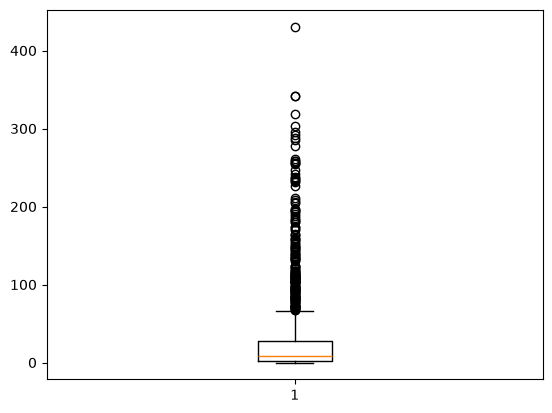

In [27]:
plt.boxplot(consumption)
plt.show()